In [131]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta

In [132]:
# Function to read station data
def read_station_data(station_file_path):
    station_data = pd.read_csv(station_file_path)
    return station_data


In [133]:
# Function to read data from each folder
def read_data(folder_path):
    all_files = glob.glob(folder_path + "/*.csv")
    df_list = []
    for file in all_files:
        df = pd.read_csv(file)
        station_name = file.split('/')[-1].split('.')[0]
        station_number = station_name.split("\\")[-1]
        station_number = station_number.split("-")[0].split("_")[-1]
        df['StationNumber'] = station_number
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

In [134]:
# Read station data
station_data = read_station_data('D:\Ayana\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\station_zone_data.csv')

# Read temperature data from Air Temperature
temperature_data = read_data('D:\Ayana\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\parameter_2')

# Read precipitation data from Precipitation
precipitation_data = read_data('D:\Ayana\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\parameter_5')

# Read precipitation data from Snow depth
snowdepth_data = read_data('D:\Ayana\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\parameter_8')

# Read the sunshine data using the function
sunshine_data = read_data('D:\Ayana\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\parameter_10')


In [135]:
# Merge station data with temperature and precipitation data
temperature_data['StationNumber'] = temperature_data['StationNumber'].astype(int)
precipitation_data['StationNumber'] = precipitation_data['StationNumber'].astype(int)
snowdepth_data['StationNumber'] = snowdepth_data['StationNumber'].astype(int)
sunshine_data['StationNumber'] = sunshine_data['StationNumber'].astype(int)

sunshine_data['DateTime'] = pd.to_datetime(sunshine_data['Datum'] + ' ' + sunshine_data['Tid (UTC)'])
sunshine_daily = sunshine_data.groupby(['StationNumber', sunshine_data['DateTime'].dt.date])['Solskenstid'].sum()
sunshine_daily_minutes = sunshine_daily / 60
sunshine_daily_minutes_df = sunshine_daily_minutes.reset_index()
sunshine_daily_minutes_df.columns = ['StationNumber', 'Date', 'SunshineDurationMinutes']

temperature_data_merged = pd.merge(temperature_data, station_data, left_on="StationNumber", right_on="stations", how="left")
precipitation_data_merged = pd.merge(precipitation_data, station_data, left_on="StationNumber", right_on="stations", how="left")
snowdepth_data_merged = pd.merge(snowdepth_data, station_data, left_on="StationNumber", right_on="stations", how="left")
sunshine_data_merged = pd.merge(sunshine_daily_minutes_df, station_data, left_on="StationNumber", right_on="stations", how="left")


In [137]:
temperature_data_merged.dropna(subset=['Latitude', 'Longitude'], inplace=True)
precipitation_data_merged.dropna(subset=['Latitude', 'Longitude'], inplace=True)
snowdepth_data_merged.dropna(subset=['Latitude', 'Longitude'], inplace=True)
sunshine_data_merged.dropna(subset=['Latitude', 'Longitude'], inplace=True)

In [138]:
temperature_data_merged['Datum'] = pd.to_datetime(temperature_data_merged['Datum'])
temperature_data_merged['DayOfYear'] = temperature_data_merged['Datum'].dt.dayofyear
X_temp = temperature_data_merged[['DayOfYear', 'Latitude', 'Longitude']]
y_temp = temperature_data_merged['Lufttemperatur']

In [139]:
precipitation_data_merged['Datum'] = pd.to_datetime(precipitation_data_merged['Datum'])
precipitation_data_merged['DayOfYear'] = precipitation_data_merged['Datum'].dt.dayofyear
X_precip = precipitation_data_merged[['DayOfYear', 'Latitude', 'Longitude']]
y_precip = precipitation_data_merged['Nederbördsmängd']

snowdepth_data_merged['Datum'] = pd.to_datetime(snowdepth_data_merged['Datum'])
snowdepth_data_merged['DayOfYear'] = snowdepth_data_merged['Datum'].dt.dayofyear
X_snow = snowdepth_data_merged[['DayOfYear', 'Latitude', 'Longitude']]
y_snow = snowdepth_data_merged['Snödjup']

sunshine_data_merged['Date'] = pd.to_datetime(sunshine_data_merged['Date'])
sunshine_data_merged['DayOfYear'] = sunshine_data_merged['Date'].dt.dayofyear
X_sunshine = sunshine_data_merged[['DayOfYear', 'Latitude', 'Longitude']]
y_sunshine = sunshine_data_merged['SunshineDurationMinutes']

In [140]:
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

In [141]:
X_train_precip, X_test_precip, y_train_precip, y_test_precip = train_test_split(X_precip, y_precip, test_size=0.2, random_state=42)

X_train_snow, X_test_snow, y_train_snow, y_test_snow = train_test_split(X_snow, y_snow, test_size=0.2, random_state=42)

X_train_sunshine, X_test_sunshine, y_train_sunshine, y_test_sunshine = train_test_split(X_sunshine, y_sunshine, test_size=0.2, random_state=42)

In [142]:
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_precip = RandomForestRegressor(n_estimators=100, random_state=42)
rf_snow = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sunshine = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_temp, y_train_temp)
rf_precip.fit(X_train_precip, y_train_precip)
rf_snow.fit(X_train_snow, y_train_snow)
rf_sunshine.fit(X_train_sunshine, y_train_sunshine)

RandomForestRegressor(random_state=42)

In [146]:
def create_features_for_current_date_and_station(station_data):
    current_date = datetime.now().date()
    day_of_year = current_date.timetuple().tm_yday    
    latitude = station_data['Latitude'].iloc[0]
    longitude = station_data['Longitude'].iloc[0]  
    return pd.DataFrame({'StationNumber': station_data['stations'].iloc[0],
                             'Date': [current_date],
                             'DayOfYear': [day_of_year],
                             'Latitude': [latitude],
                             'Longitude': [longitude]})

In [147]:
def predict_for_station(X, rf_temp, rf_precip, rf_snow, rf_sunshine, temperature_data_merged, precipitation_data_merged, snowdepth_data_merged, sunshine_data_merged):
    station_number = X['StationNumber'].iloc[0]
    current_date = X['Date'].iloc[0]       
    
    next_day = current_date + timedelta(days=1)
    next_day_of_year = next_day.timetuple().tm_yday
    
    X['Date'] = next_day
    X['DayOfYear'] = next_day_of_year
    
    # Predict temperature for the station
    temperature_data_available = station_number in temperature_data_merged['StationNumber'].unique()
    
    # Check if there's data available for precipitation for the station
    precipitation_data_available = station_number in precipitation_data_merged['StationNumber'].unique()

    # Check if there's data available for snow depth for the station
    snowdepth_data_available = station_number in snowdepth_data_merged['StationNumber'].unique()
    
    # Check if there's data available for snow depth for the station
    sunshine_data_available = station_number in sunshine_data_merged['StationNumber'].unique()       
    
    # Predict temperature for the station if data is available, otherwise set to NaN
    if temperature_data_available:
        temperature_predictions = rf_temp.predict(X[['DayOfYear', 'Latitude', 'Longitude']])    
    else:
        temperature_predictions = [np.nan] * len(X)
    
    # Predict precipitation for the station if data is available, otherwise set to NaN
    if precipitation_data_available:
        precipitation_predictions = rf_precip.predict(X[['DayOfYear', 'Latitude', 'Longitude']])
    else:
        precipitation_predictions = [np.nan] * len(X) 
        
    # Predict sunshine for the station if data is available, otherwise set to NaN
    if sunshine_data_available:
        sunshine_predictions = rf_sunshine.predict(X[['DayOfYear', 'Latitude', 'Longitude']])
    else:
        sunshine_predictions = [np.nan] * len(X)
        
    # Predict snow depth for the station if data is available, otherwise set to NaN
    if snowdepth_data_available:
        snowdepth_predictions = rf_snow.predict(X[['DayOfYear', 'Latitude', 'Longitude']])
    else:
        snowdepth_predictions = [np.nan] * len(X)
        
    return pd.DataFrame({'StationNumber': X['StationNumber'],
                         'Date': X['Date'],
                         'Average_AirTemperature': temperature_predictions,
                         'Average_Precipitation': precipitation_predictions,
                         'Average_SnowDepth': snowdepth_predictions,
                         'Average_Sunshine(Minutes)': sunshine_predictions})


In [148]:
station_predictions = pd.DataFrame(columns=['StationNumber', 'Date', 'Average_AirTemperature', 'Average_Precipitation', 'Average_SnowDepth', 'Average_Sunshine(Minutes)'])

In [149]:
for station_number, station_data in station_data.groupby('stations'):    
    currentData = create_features_for_current_date_and_station(station_data)
    # Predict for the stations
    station_predictions = station_predictions.append(predict_for_station(currentData, rf_temp, rf_precip, rf_snow, rf_sunshine, temperature_data_merged, precipitation_data_merged, snowdepth_data_merged, sunshine_data_merged))


C:\Users\AppData\Local\Temp\ipykernel_10864\1232981745.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  station_predictions = station_predictions.append(predict_for_station(currentData, rf_temp, rf_precip, rf_snow, rf_sunshine, temperature_data_merged, precipitation_data_merged, snowdepth_data_merged, sunshine_data_merged))
C:\Users\AppData\Local\Temp\ipykernel_10864\1232981745.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  station_predictions = station_predictions.append(predict_for_station(currentData, rf_temp, rf_precip, rf_snow, rf_sunshine, temperature_data_merged, precipitation_data_merged, snowdepth_data_merged, sunshine_data_merged))
C:\Users\AppData\Local\Temp\ipykernel_10864\1232981745.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future versio

In [150]:
station_predictions_filtered = station_predictions.dropna(subset=['Average_AirTemperature', 'Average_Precipitation', 'Average_SnowDepth', 'Average_Sunshine(Minutes)'], how='all')
station_predictions_filtered.reset_index(drop=True, inplace=True)


station_predictions_filtered.to_csv(r'D:\user\MachineLearning\ws1\wettersol\smhi_data_2022-today\smhi_data_2022-today\predictions-stationwise.csv', index=False)

C:\Users\AppData\Local\Temp\ipykernel_10864\3777076119.py:10: FutureWarning: Dropping invalid columns in DataFrameGroupBy.mean is deprecated. In a future version, a TypeError will be raised. Before calling .mean, select only columns which should be valid for the function.
  aggregated_predictions = station_predictions_filtered[station_predictions_filtered['StationNumber'].isin(stations_with_sunshine)].groupby('StationNumber').mean()


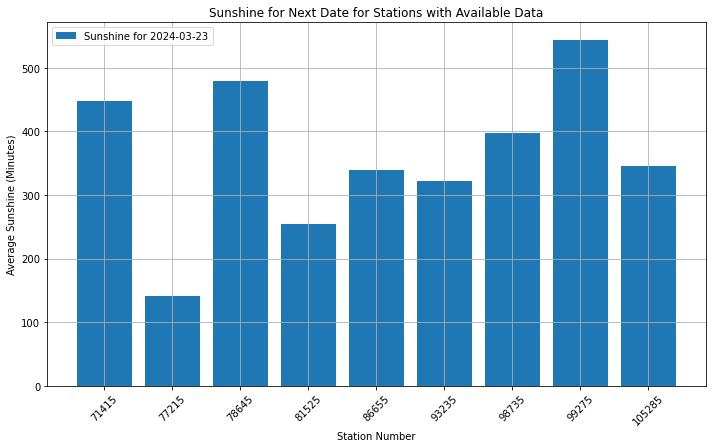

In [151]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Assuming predictions is the DataFrame containing predictions for all stations for the next day

# Filter stations with sunshine data
stations_with_sunshine = station_predictions_filtered.dropna(subset=['Average_Sunshine(Minutes)'])['StationNumber'].unique()

# Aggregate predictions for stations with sunshine data
aggregated_predictions = station_predictions_filtered[station_predictions_filtered['StationNumber'].isin(stations_with_sunshine)].groupby('StationNumber').mean()

# Convert station numbers to strings
station_numbers_str = [str(station_number) for station_number in aggregated_predictions.index]

# Get the next date
next_date = datetime.now().date() + timedelta(days=1)

# Create a new figure
plt.figure(figsize=(10, 6))

# Plot next day predicted sunshine for stations with sunshine data
plt.bar(station_numbers_str, aggregated_predictions['Average_Sunshine(Minutes)'], label=f'Sunshine for {next_date}')

# Add labels and legend
plt.xlabel('Station Number')
plt.ylabel('Average Sunshine (Minutes)')
plt.title(f'Sunshine for Next Date for Stations with Available Data')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [197]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict temperature for the test set
y_pred_temp = rf_temp.predict(X_test_temp)

# Calculate MAE
mae_temp = mean_absolute_error(y_test_temp, y_pred_temp)

# Calculate MSE
mse_temp = mean_squared_error(y_test_temp, y_pred_temp)

# Calculate RMSE
rmse_temp = np.sqrt(mse_temp)

# Calculate R2
r2_temp = r2_score(y_test_temp, y_pred_temp)


print("\nsunshine:")
print("MAE:", mae_temp)
print("MSE:", mse_temp)
print("RMSE:", rmse_temp)
print("R2:", r2_temp)



sunshine:
MAE: 2.0433279914553544
MSE: 7.43105971285423
RMSE: 2.7259970126275324
R2: 0.8680239837790499
